<a href="https://colab.research.google.com/github/90splayer/AI-HEALTH-LAB/blob/main/week_06_diabetes_linear_regression_21_March.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First you will need to load the required packages.

In [1]:
# Chibuzor Ojogbo
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import pandas as pd
%matplotlib inline


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Use the "diabetes.csv" file which was located in the same folder with this code. The diabetes data was adapted from an original research paper  and more information on the dataset can be found here: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

In [4]:
diabetes = pd.read_csv('/content/drive/My Drive/diabetes.csv')

Check the type of the object. Then investigate whether there are any missing values.

In [5]:
print(type(diabetes))

<class 'pandas.core.frame.DataFrame'>


In [6]:
diabetes.isnull().values.any()

np.False_

Visualise the first lines of the data

In [7]:
diabetes.head()

,AGE,SEX,BMI,BP,tc,ldl,hdl,tch,ltg,glu,y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


Perform descriptive statistics in the data and check whether the values are within the biologically expected range.

In [8]:
diabetes.describe()

,AGE,SEX,BMI,BP,tc,ldl,hdl,tch,ltg,glu,y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


Plot a histigram of variables and check the distributions. Then  check mean, median and standard deviations of the variables.

(array([19., 28., 47., 53., 55., 85., 69., 47., 33.,  6.]),
 array([19., 25., 31., 37., 43., 49., 55., 61., 67., 73., 79.]),
 <BarContainer object of 10 artists>)

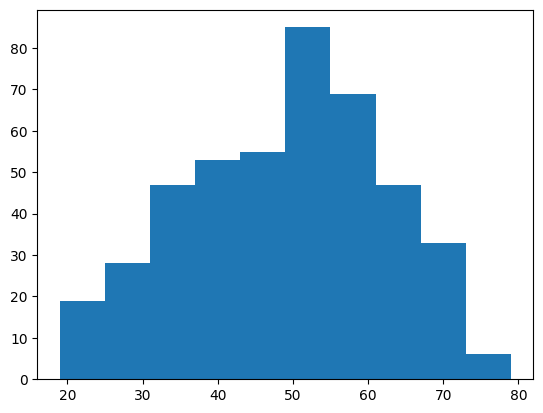

In [9]:
plt.hist(diabetes['AGE'])


In [10]:
x = np.mean(diabetes['AGE'])
print(x)

48.51809954751131


In [11]:
x = np.std(diabetes['AGE'])

print(x)

13.09419020798002


In [12]:
x = np.median(diabetes['AGE'])
print(x)

50.0


Generate a correlation matrix and investigate the variables

In [13]:
diabetes.corr()

,AGE,SEX,BMI,BP,tc,ldl,hdl,tch,ltg,glu,y
AGE,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
SEX,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
BMI,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
BP,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
tc,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
ldl,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
hdl,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
tch,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
ltg,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
glu,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


Select two correlated variables from the corelation matrix you generated and plot their correlation with each other

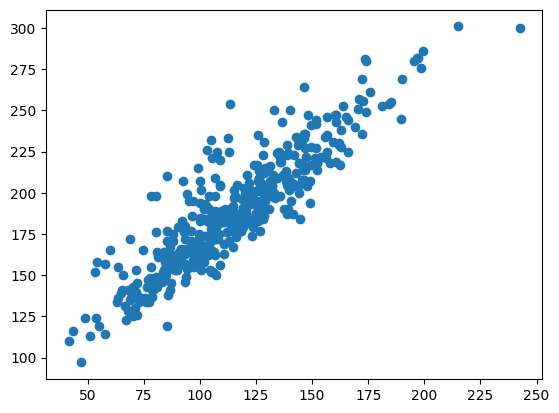

In [14]:
plt.scatter(diabetes['ldl'], diabetes['tc'])
plt.show()

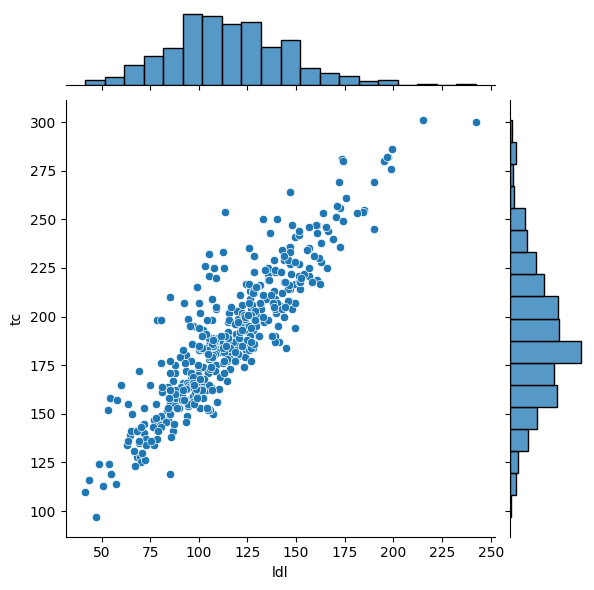

In [15]:
sns.jointplot(x='ldl',y='tc', data=diabetes)

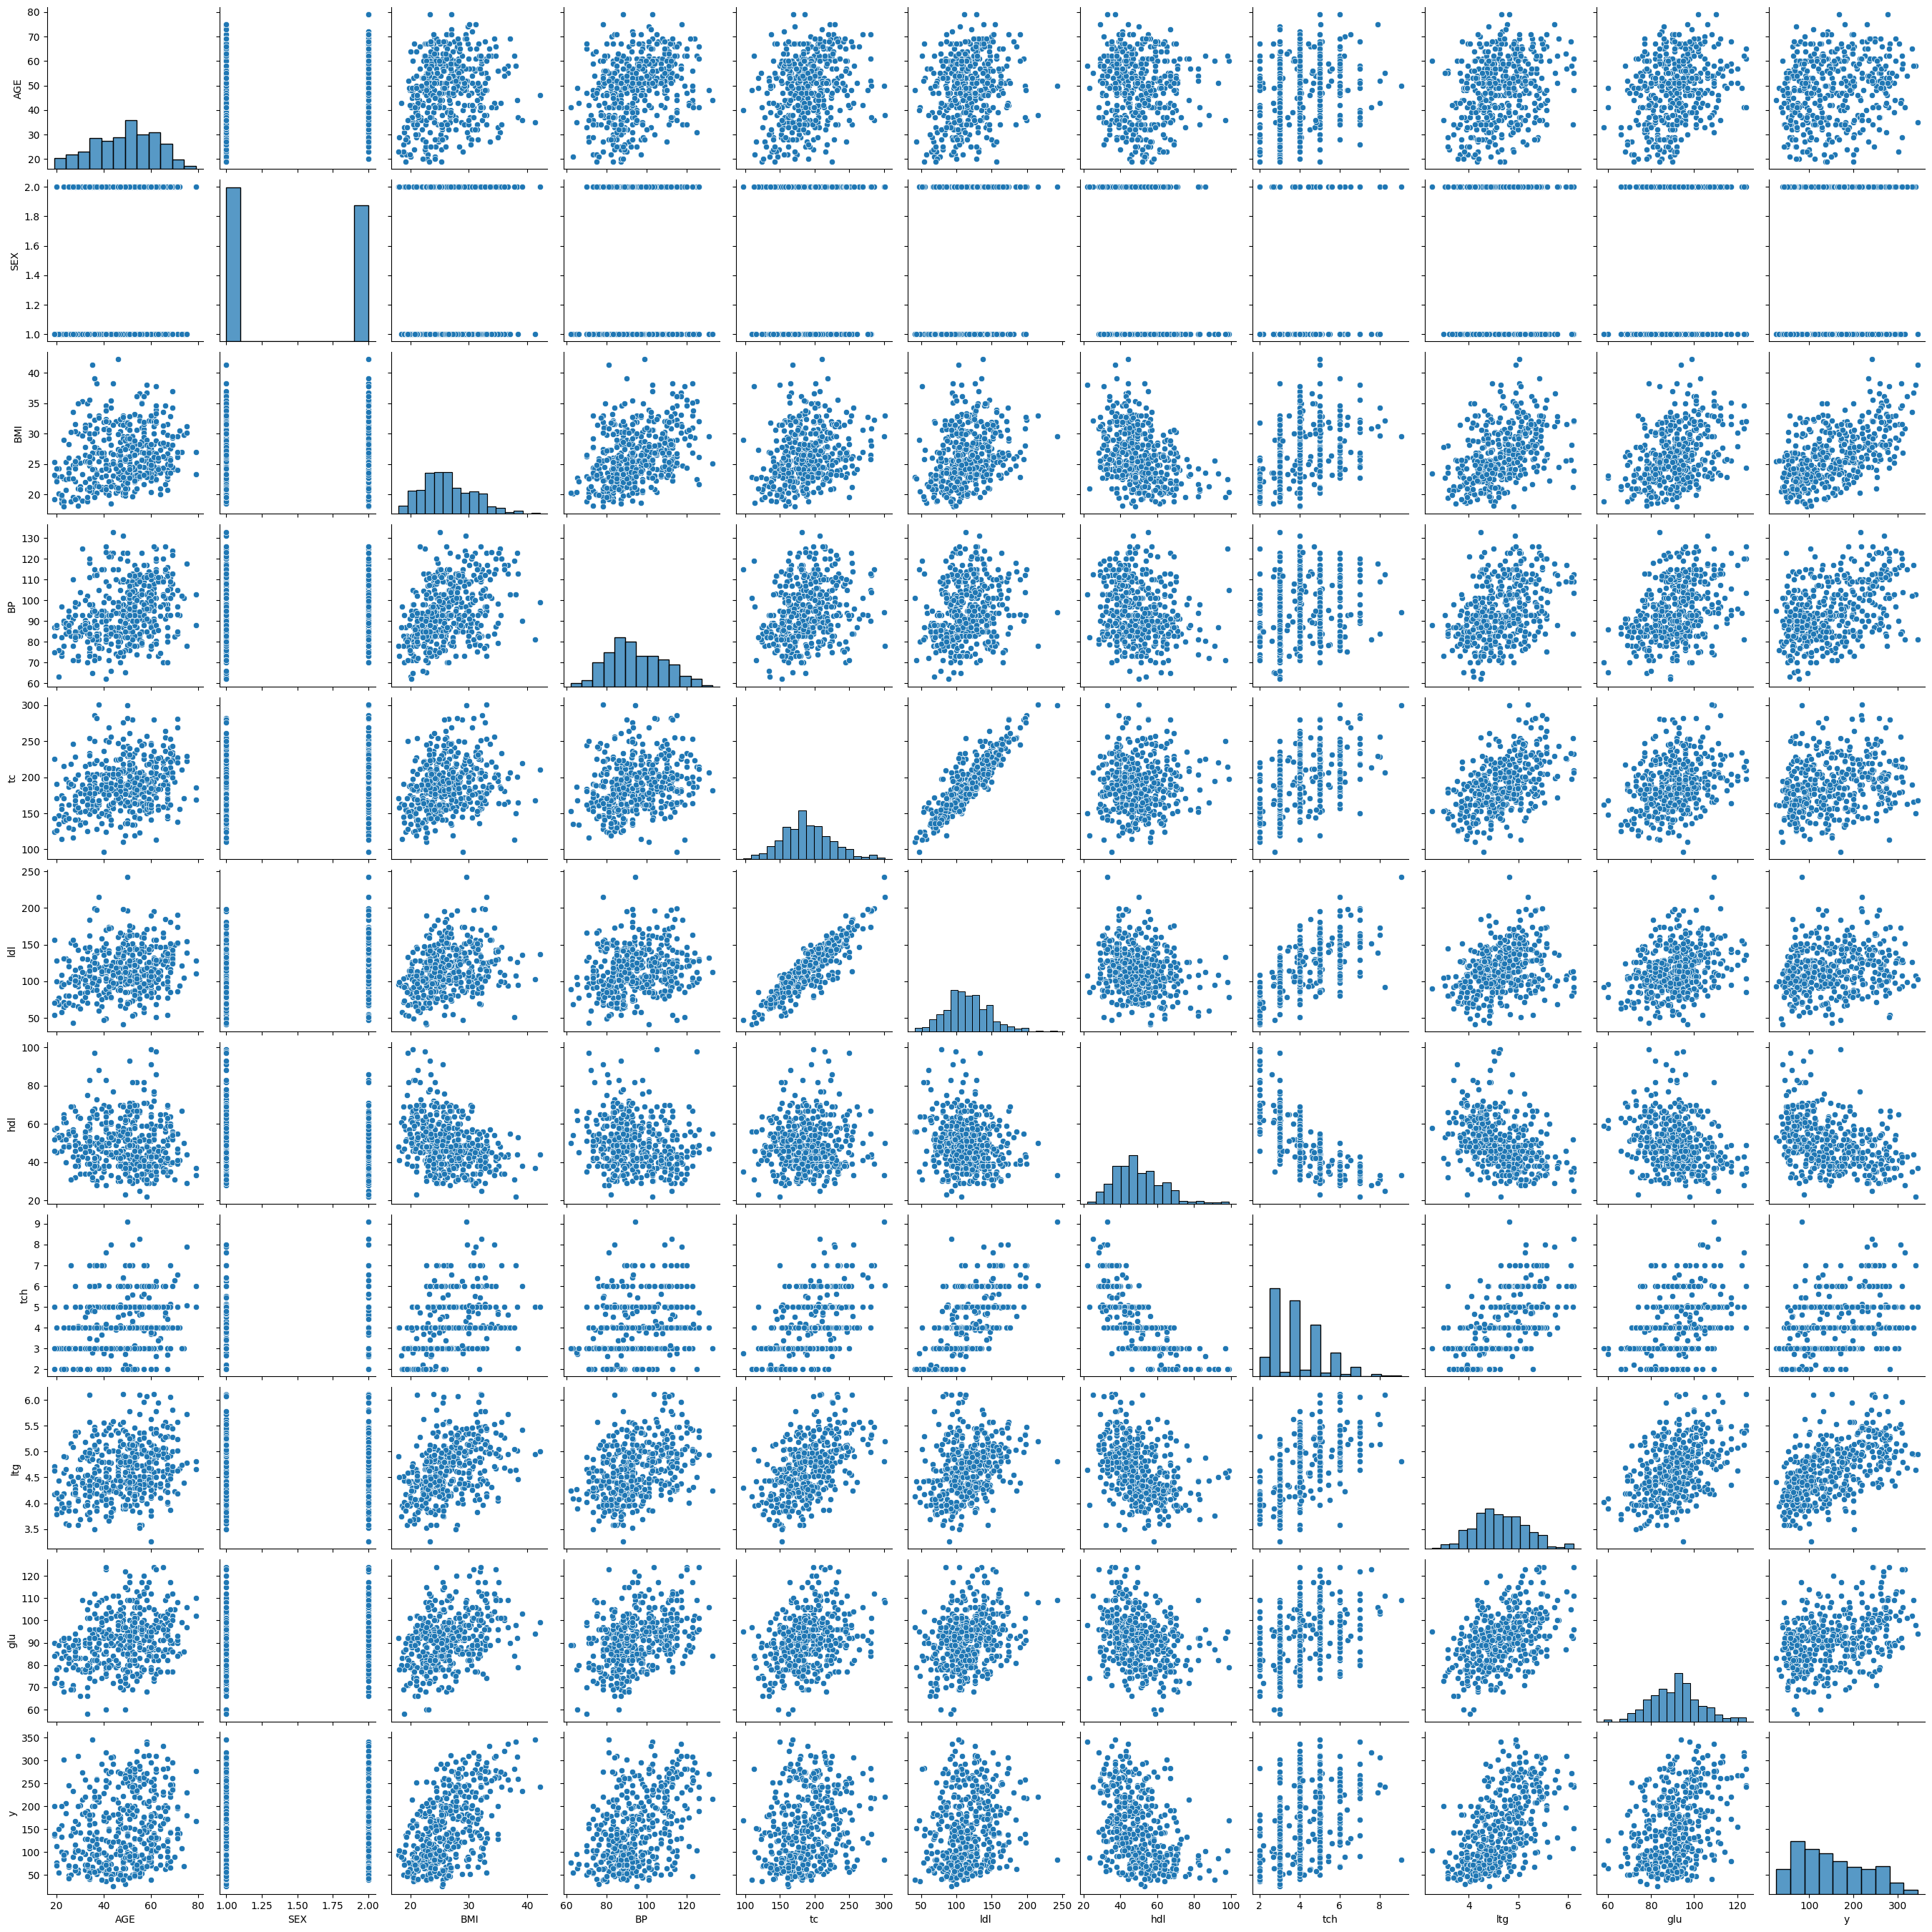

In [16]:
sns.pairplot(data=diabetes)

Create a linear regression model

In [29]:
X = diabetes[['AGE', 'BMI']]
y = diabetes['BP']

In [30]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

LinearRegression()

Now from your fitted model, estimate the blood pressure for a person who is 35 years old and BMI of 30.

In [31]:
predictedBP = regr.predict([[72, 30.5]])
print(predictedBP)

[105.83104069]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Now do the same yourself: estimate the blood  pressure of the same person by using the coefficients and the intercept from the regression model you fitted.

In [33]:
print(regr.coef_)


[0.28650631 1.0805261 ]


In [34]:
print(regr.intercept_)

52.24654048996419


Now, put the estimated values in the regression formula and calculate the predicted value by hand.

In [23]:
x1 = 35
x2 = 30

y = regr.intercept_ + regr.coef_[0]*x1 + regr.coef_[1]*x2

print(y)

94.69004431618694


Next, try to predict the age of a person by using hdl and blood pressure (BP) variables

In [32]:
X2 = diabetes[['hdl', 'BP']]
y2 = diabetes['AGE']

In [35]:
regr2 = linear_model.LinearRegression()
regr2.fit(X2, y2)

LinearRegression()

In [37]:
predictedAGE = regr2.predict([[93, 41]])
print(predictedAGE)
# Chibuzor Ojogbo

[30.91742934]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [38]:
X3 = diabetes[['ldl', 'tc']]
y3 = diabetes['AGE']

In [39]:
regr3 = linear_model.LinearRegression()
regr3.fit(X3, y3)

LinearRegression()

In [40]:
predictedAGE = regr3.predict([[93.6, 156]])
print(predictedAGE)

[45.1224621]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [45]:
X4 = diabetes[['BP', 'glu']]
y4 = diabetes['AGE']

In [46]:
regr4 = linear_model.LinearRegression()
regr4.fit(X4, y4)

LinearRegression()

In [47]:
predictedAGE3 = regr4.predict([[93.0, 85]])
print(predictedAGE3)

[46.67903298]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
